In [16]:
# ^NSEI ,GC=F

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt


[*********************100%***********************]  2 of 2 completed


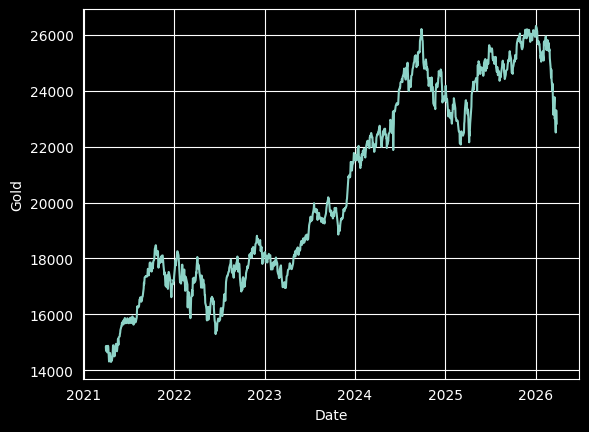

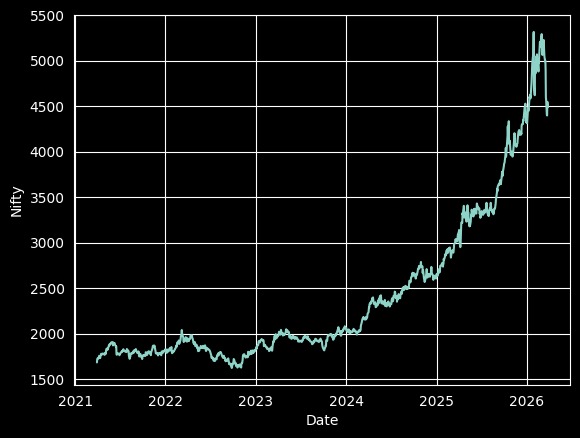

In [18]:
end = dt.date.today()
start = end - dt.timedelta(days=365*5)
tickers = "^NSEI" ,"GC=F"
df = yf.download(tickers,start = start,end = end,auto_adjust = True)['Close']
df.columns = ['Nifty','Gold']
df.dropna(inplace = True)

sns.lineplot(df.Gold)
plt.show()

sns.lineplot(df.Nifty)
plt.show()

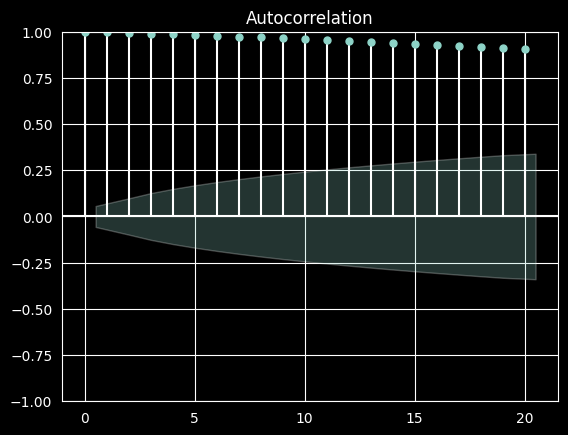

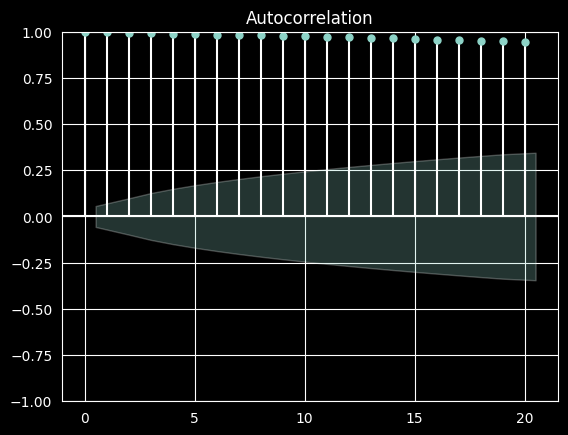

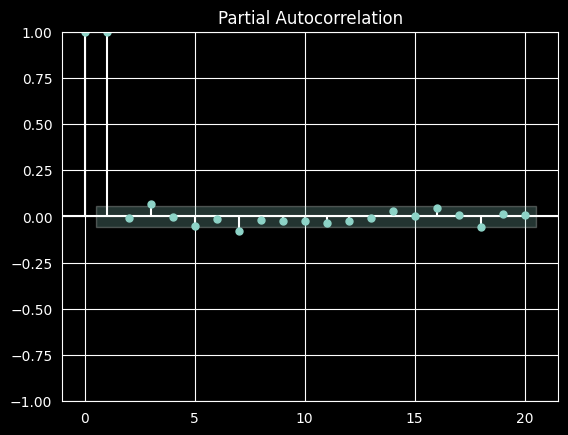

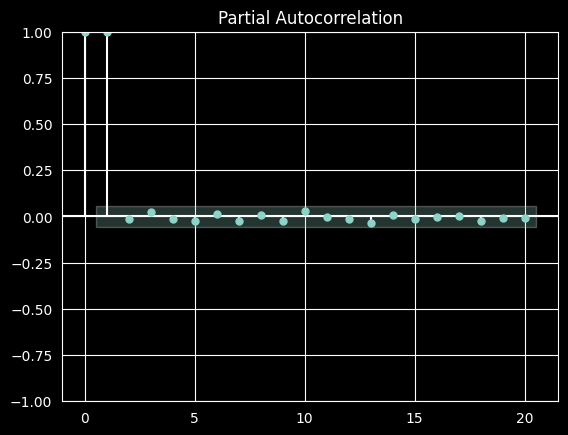

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Nifty'], lags=20)
plt.show()

plot_acf(df['Gold'], lags=20)
plt.show()

from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Nifty'], lags=20)
plt.show()

plot_pacf(df['Gold'], lags=20)
plt.show()


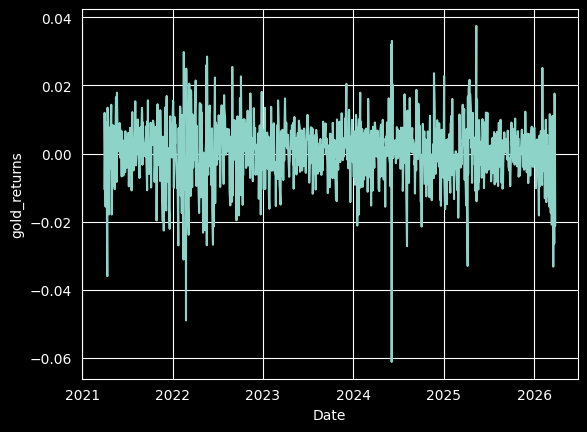

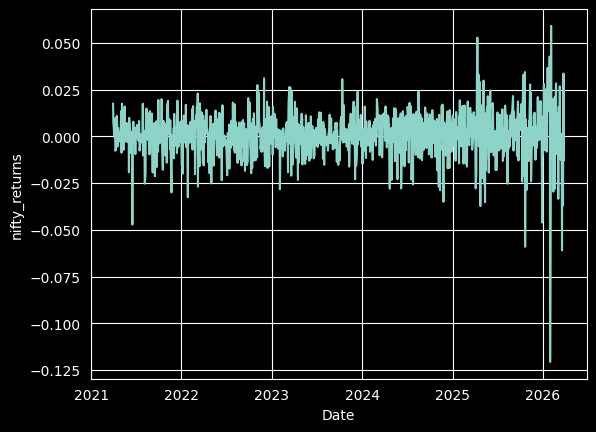

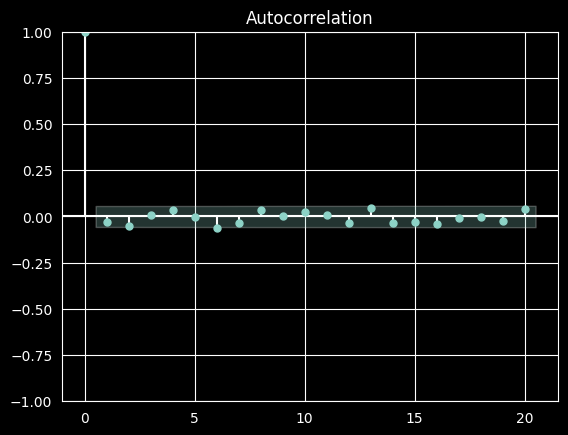

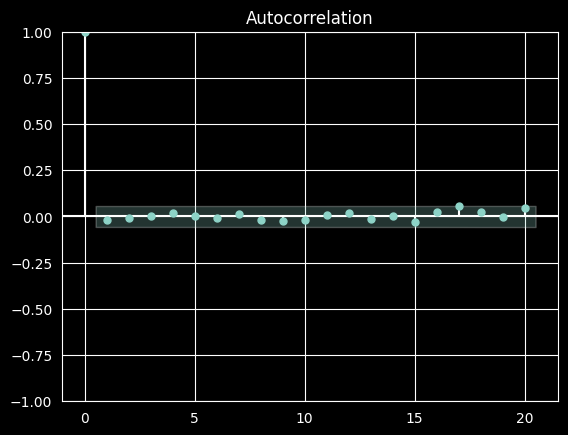

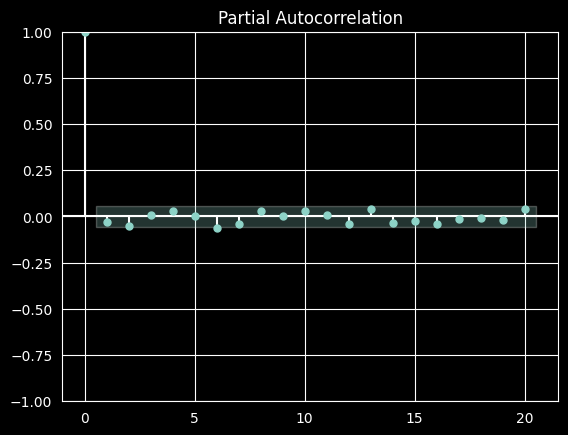

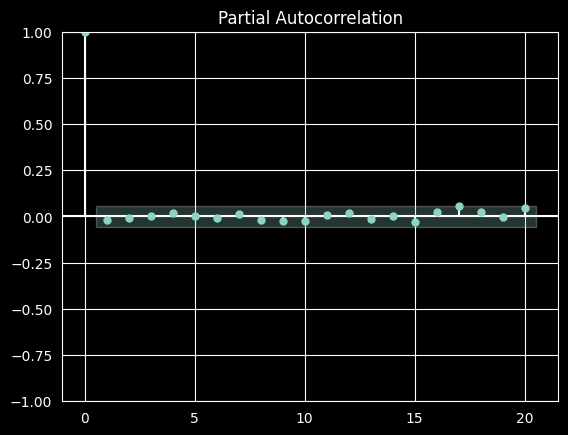

In [20]:
df['gold_returns'] = np.log(df['Gold']/df['Gold'].shift(1))
df['nifty_returns'] = np.log(df['Nifty']/df['Nifty'].shift(1))

df.dropna(inplace = True)

sns.lineplot(df.gold_returns)
plt.show()

sns.lineplot(df.nifty_returns)
plt.show()



plot_acf(df['nifty_returns'], lags=20)
plt.show()

plot_acf(df['gold_returns'], lags=20)
plt.show()

plot_pacf(df['nifty_returns'], lags=20)
plt.show()

plot_pacf(df['gold_returns'], lags=20)
plt.show()

In [21]:
# Decomposition means component which are trend,season/pattern and randomness
# for checking data has trend,season/pattern adf and kpps test

from statsmodels.tsa.stattools import adfuller
results = adfuller(df['nifty_returns'])
print('ADF Statistics:', results[0])
print('p-value:', results[1])

from statsmodels.tsa.stattools import kpss

result = kpss(df['nifty_returns'],regression='c')
print("KPS Statistics:", result[0])
print("p-value:", result[1])


ADF Statistics: -26.09563053823153
p-value: 0.0
KPS Statistics: 0.3442537663203959
p-value: 0.1


/tmp/ipykernel_4947/3146492117.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(df['nifty_returns'],regression='c')
